In [1718]:
import pandas as pd
import numpy as np

# Part 1. Data Validation, Cleaning & Feature Engineering


## Objective
Prepare Orders dataset for further KPI and profitability analysis.


## Tasks
1. Validate structure and data types
2. Check data quality (missing values, duplicates)
3. Engineer shipping duration feature
4. Detect data anomalies

## Data Loading

In [128]:
file_path = "CV_Sample - Superstore - 2025.xls"

orders = pd.read_excel(file_path, sheet_name="Orders", parse_dates=False)
people = pd.read_excel(file_path, sheet_name="People",parse_dates=False)
returns = pd.read_excel(file_path, sheet_name="Returns",parse_dates=False)

## Initial Overview

In [113]:
orders.shape

(10194, 21)

In [130]:
orders.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State/Province            object
Postal Code               object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

Dataset contains 10194 rows and 21 columns.
Date columns are stored correctly as datetime64.

## Data Quality Checks


### Missing Values

In [156]:
orders.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

No missing values found

### Duplicate Key Check

In [180]:
orders.duplicated().sum()

0

No duplicate values found

### Numerical Range Validation

In [186]:
numeric_cols=['Sales','Quantity','Discount','Profit']
orders[numeric_cols].describe()

,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,228.225854,3.791838,0.155385,28.673417
std,619.906839,2.228317,0.206249,232.465115
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.220000,2.000000,0.000000,1.760800
50%,53.910000,3.000000,0.200000,8.690000
75%,209.500000,5.000000,0.200000,29.297925
max,22638.480000,14.000000,0.800000,8399.976000


In [190]:
invalid_sales = (orders["Sales"] < 0).sum()
invalid_quantity = (orders["Quantity"] <= 0).sum()
invalid_discount_low = (orders["Discount"] < 0).sum()
invalid_discount_high = (orders["Discount"] > 1).sum()
negative_profit_count = (orders["Profit"] < 0).sum()
negative_profit_share = negative_profit_count / len(orders)

In [210]:
range_validation_summary = pd.Series({
    "Negative Sales": invalid_sales,
    "Negative Quantity": invalid_quantity,
    "Negative Discount": invalid_discount_low,
    "Too high Discount": invalid_discount_high,
    "Negative Profit (count)": negative_profit_count,
    "Negative Profit (share)": round(negative_profit_share,3)
})
range_validation_summary

Negative Sales                0.000
Negative Quantity             0.000
Negative Discount             0.000
Too high Discount             0.000
Negative Profit (count)    1901.000
Negative Profit (share)       0.186
dtype: float64

18.6% of transactions generate negative profit — 
requires further category and discount-level investigation.

### Categorical Validation

In [290]:
categorical_cols=['Segment','Region','Category','Ship Mode']

In [292]:
for col in categorical_cols:
    print(f"\n{col}")
    print(orders[col].value_counts(dropna=False))


Segment
Segment
Consumer       5281
Corporate      3090
Home Office    1823
Name: count, dtype: int64

Region
Region
West       3253
East       2986
Central    2335
South      1620
Name: count, dtype: int64

Category
Category
Office Supplies    6128
Furniture          2201
Technology         1865
Name: count, dtype: int64

Ship Mode
Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64


In [332]:
missing_values = orders[categorical_cols].isna().sum()

In [328]:
for col,val in missing_values.items():
    print(f'{col}: {val}')

Segment: 0
Region: 0
Category: 0
Ship Mode: 0


No missing values found

## Shipping Validation

### Invalid Shipping Dates

In [220]:
orders['ship_days']=(orders['Ship Date']-orders['Order Date']).dt.days
negative_shipping=orders[orders["ship_days"] < 0]
negative_shipping_count=len(negative_shipping)
negative_shipping_count

0

### Extreme Shipping Duration

In [223]:
extreme_shipping = orders[orders["ship_days"] > 30]
extreme_shipping_count=len(extreme_shipping)
extreme_shipping_count


0

### Logical Validation Summary

In [283]:
logical_validation_summary = pd.Series({
    "Ship Date < Order Date": negative_shipping_count,
    "Shipping > 30 days": extreme_shipping_count,
})

logical_validation_summary

Ship Date < Order Date    0
Shipping > 30 days        0
dtype: int64

## Outlier Review

### Top-10 Longest Shipping Duration

In [257]:
top_ship_days=(orders.sort_values('ship_days',ascending=True).tail(10)
                [["Order ID", "Customer Name", "Region", "ship_days"]])
top_ship_days

,Order ID,Customer Name,Region,ship_days
9409,US-2025-157483,Emily Phan,Central,7
9416,US-2025-143455,Max Ludwig,East,7
2287,US-2023-138219,Bart Pistole,West,7
2300,US-2023-132948,Mark Van Huff,West,7
4567,US-2024-134789,Christine Kargatis,South,7
2324,US-2023-159513,John Dryer,West,7
9393,US-2025-128447,Michael Chen,West,7
8006,US-2025-137085,Carol Triggs,West,7
1699,CA-2022-153623,James Peterman,East,11
1698,CA-2022-153623,James Peterman,East,11


In [360]:
max_ship_days = orders['ship_days'].max()
count_max_ship_days = (orders['ship_days']==max_ship_days).sum()
count_max_ship_days

2

### Top-10 Highest Discount

In [347]:
top_discount=(orders.sort_values('Discount', ascending=False).head(10)
                                [["Order ID", "Customer Name", "Category",
                                  "Sales", "Profit", "Discount"]])
top_discount

,Order ID,Customer Name,Category,Sales,Profit,Discount
7005,US-2025-118773,Tom Prescott,Office Supplies,12.992,-32.4800,0.8
5763,US-2024-156097,Eugene Hildebrand,Office Supplies,2.308,-3.4620,0.8
5879,US-2024-108644,Sarah Jordon,Office Supplies,1.964,-3.2406,0.8
2525,US-2023-129217,Dennis Pardue,Office Supplies,70.970,-191.6190,0.8
5851,US-2024-132017,Matt Hagelstein,Office Supplies,6.816,-11.5872,0.8
5850,US-2024-149790,Shahid Collister,Office Supplies,15.624,-24.9984,0.8
5848,US-2024-143406,Lisa Ryan,Office Supplies,93.032,-251.1864,0.8
9076,US-2025-163160,Troy Staebel,Office Supplies,96.784,-145.1760,0.8
7915,US-2025-131618,Luke Schmidt,Office Supplies,9.360,-16.3800,0.8
2554,US-2023-117184,Odella Nelson,Office Supplies,33.280,-49.9200,0.8


In [354]:
max_discount = orders['Discount'].max()
count_max_discount = (orders['Discount']==max_discount).sum()
count_max_discount

301

### Top-10 Most Negative Profit

In [351]:
top_negative_profit = (orders.sort_values('Profit',ascending=True).head(10)
                [["Order ID", "Customer Name", "Category", 
                  "Sales", "Profit", "Discount"]])
top_negative_profit

,Order ID,Customer Name,Category,Sales,Profit,Discount
6398,US-2024-108196,Cindy Stewart,Technology,4499.985,-6599.9780,0.7
9318,US-2025-168116,Grant Thornton,Technology,7999.980,-3839.9904,0.5
821,US-2022-169019,Luke Foster,Office Supplies,2177.584,-3701.8928,0.8
7441,US-2025-134845,Sharelle Roach,Technology,2549.985,-3399.9800,0.7
9845,US-2025-122714,Henry Goldwyn,Office Supplies,1889.990,-2929.4845,0.8
4037,US-2023-147830,Natalie Fritzler,Technology,1799.994,-2639.9912,0.7
9557,US-2025-131254,Nathan Cano,Office Supplies,1525.188,-2287.7820,0.8
2108,US-2023-116638,Joseph Holt,Furniture,4297.644,-1862.3124,0.4
4570,US-2024-130946,Zuschuss Carroll,Office Supplies,1088.792,-1850.9464,0.8
226,US-2022-145317,Sean Miller,Technology,22638.480,-1811.0784,0.5


### Outlier Summary

In [362]:
outlier_summary = pd.Series({
    "Max shipping days": orders['ship_days'].max(),
    "Max shipping days count": count_max_ship_days,
    "Min profit": orders['Profit'].min(),
    "Max discount": orders['Discount'].max(),
    "Max discount count": count_max_discount,
    
})

outlier_summary

Max shipping days            11.000
Max shipping days count       2.000
Min profit                -6599.978
Max discount                  0.800
Max discount count          301.000
dtype: float64

## Summary. Part 1

In [864]:
data_quality_summary = pd.Series({
    "Total rows": total_rows,
    "Total missing values": total_missing,
    "Duplicate Row ID": duplicate_row_id,
    "Invalid discount values": invalid_discount,
    "Non-positive quantity": non_positive_quantity,
    "Negative ship_days": negative_ship_days,
    "Extreme ship_days (>30)": extreme_ship_days,
    "Share of negative profit": negative_profit_share
})

data_quality_summary

Total rows                  10194.0000
Total missing values            0.0000
Duplicate Row ID                0.0000
Invalid discount values         0.0000
Non-positive quantity           0.0000
Negative ship_days              0.0000
Extreme ship_days (>30)         0.0000
Share of negative profit        0.1865
dtype: float64

The dataset contains 10,194 rows with no missing values and no duplicate primary keys,
confirming structural integrity.
All numeric validation checks passed:
No invalid discount values
No non-positive quantities
No negative shipping durations
No extreme shipping delays (>30 days)

The 18.65% share of negative-profit transactions requires further investigation to understand the underlying drivers.

# Part 2. KPI & Business Overview

## Objective
To assess overall business performance and identify key profit drivers and risk areas 
across regions, segments, and product categories.


## Tasks
1. Calculate Global KPI
2. Build KPI Breakdown by different dimensions
3. Identify Performance Leaders
4. Analyze Losses

## Global KPI

In [732]:
total_sales=orders['Sales'].sum()
total_profit=orders['Profit'].sum()
profit_margin=total_profit/total_sales
total_orders=orders['Order ID'].nunique()
order_sales=orders.groupby('Order ID')['Sales'].sum()
avg_order_value=order_sales.mean()
avg_discount=orders['Discount'].mean()

In [734]:
global_kpi = pd.Series({
    "Total Sales": total_sales,
    "Total Profit": total_profit,
    "Profit Margin": profit_margin,
    "Total Orders": total_orders,
    "Average Order Value": avg_order_value,
    "Average Discount": avg_discount,
})

global_kpi.round(3)

Total Sales            2326534.354
Total Profit            292296.815
Profit Margin                0.126
Total Orders              5111.000
Average Order Value        455.201
Average Discount             0.155
dtype: float64

## KPI Breakdown by Region, Segment & Category

In [736]:
kpi_region=orders.groupby('Region').agg({'Sales':'sum','Profit':'sum'})
kpi_region['Profit Margin']=kpi_region['Profit']/kpi_region['Sales']
unique_orders_region=orders.groupby('Region')['Order ID'].nunique()
kpi_region['Total_Orders']=unique_orders_region
kpi_region=kpi_region.round(3)
kpi_region

,Sales,Profit,Profit Margin,Total_Orders
Region,,,,
Central,503170.673,39865.307,0.079,1179
East,691828.168,94883.260,0.137,1475
South,391721.905,46749.430,0.119,822
West,739813.608,110798.817,0.150,1635


In [738]:
kpi_segment=orders.groupby('Segment').agg({'Sales':'sum','Profit':'sum'})
kpi_segment['Profit Margin']=kpi_segment['Profit']/kpi_segment['Sales']
unique_orders_segment=orders.groupby('Segment')['Order ID'].nunique()
kpi_segment['Total_Orders']=unique_orders_segment
kpi_segment = kpi_segment.round(3)
kpi_segment

,Sales,Profit,Profit Margin,Total_Orders
Segment,,,,
Consumer,1170659.787,136371.446,0.116,2628
Corporate,715806.135,94249.640,0.132,1552
Home Office,440068.432,61675.728,0.140,931


In [740]:
kpi_category=orders.groupby('Category').agg({'Sales':'sum','Profit':'sum'})
kpi_category['Profit Margin']=kpi_category['Profit']/kpi_category['Sales']
unique_orders_category=orders.groupby('Category')['Order ID'].nunique()
kpi_category['Total_Orders']=unique_orders_category
kpi_category = kpi_category.round(3)
kpi_category

,Sales,Profit,Profit Margin,Total_Orders
Category,,,,
Furniture,754747.761,19729.996,0.026,1819
Office Supplies,731893.314,126023.443,0.172,3812
Technology,839893.279,146543.376,0.174,1560


## Leading Region, Segment & Category

In [742]:
sales_max_r=kpi_region['Sales'].max()
region_name = kpi_region['Sales'].idxmax()
print(f'Region with the highest sales: {region_name} ({sales_max_r})')

Region with the highest sales: West (739813.608)


In [744]:
margin_max_c=kpi_category['Profit Margin'].max()
category_name = kpi_category['Profit Margin'].idxmax()
print(f'Category with the highest margin: {category_name} ({margin_max_c})')

Category with the highest margin: Technology (0.174)


In [746]:
demand_max_s=kpi_segment['Total_Orders'].max()
segment_name = kpi_segment['Total_Orders'].idxmax()
print(f'Segment with the highest demand: {segment_name} ({demand_max_s})')

Segment with the highest demand: Consumer (2628)


## Loss Analysis

In [748]:
orders['is_loss']=orders['Profit']<0
loss_by_cat_share=orders.groupby('Category')['is_loss'].mean()
loss_by_region_share=orders.groupby('Region')['is_loss'].mean()
loss_by_segment_share=orders.groupby('Segment')['is_loss'].mean()

In [750]:
loss_by_cat_share

Category
Furniture          0.332576
Office Supplies    0.146540
Technology         0.145308
Name: is_loss, dtype: float64

In [752]:
loss_by_region_share

Region
Central    0.319914
East       0.192230
South      0.159877
West       0.098678
Name: is_loss, dtype: float64

In [754]:
loss_by_segment_share

Segment
Consumer       0.192767
Corporate      0.181877
Home Office    0.176083
Name: is_loss, dtype: float64

In [756]:
loss_by_cat_sum=orders[orders['Profit'] < 0].groupby('Category')['Profit'].sum()
loss_by_region_sum=orders[orders['Profit'] < 0].groupby('Region')['Profit'].sum()
loss_by_segment_sum=orders[orders['Profit'] < 0].groupby('Segment')['Profit'].sum()

In [758]:
loss_by_cat_sum

Category
Furniture         -61675.1837
Office Supplies   -56783.8283
Technology        -38579.9182
Name: Profit, dtype: float64

In [760]:
loss_by_region_sum

Region
Central   -56371.1035
East      -50187.8375
South     -27504.8323
West      -22975.1569
Name: Profit, dtype: float64

In [762]:
loss_by_segment_sum

Segment
Consumer      -85301.0749
Corporate     -44934.3022
Home Office   -26803.5531
Name: Profit, dtype: float64

In [764]:
loss_summary_category = pd.concat(
    [loss_by_cat_sum, loss_by_cat_share],
    axis=1
)

loss_summary_category.columns = ['Total_Loss', 'Loss_Share']
loss_summary_category

,Total_Loss,Loss_Share
Category,,
Furniture,-61675.1837,0.332576
Office Supplies,-56783.8283,0.146540
Technology,-38579.9182,0.145308


In [766]:
loss_summary_region = pd.concat(
    [loss_by_region_sum, loss_by_region_share],
    axis=1
)

loss_summary_region.columns = ['Total_Loss', 'Loss_Share']
loss_summary_region

,Total_Loss,Loss_Share
Region,,
Central,-56371.1035,0.319914
East,-50187.8375,0.192230
South,-27504.8323,0.159877
West,-22975.1569,0.098678


In [768]:
loss_summary_segment = pd.concat(
    [loss_by_segment_sum, loss_by_segment_share],
    axis=1
)

loss_summary_segment.columns = ['Total_Loss', 'Loss_Share']
loss_summary_segment

,Total_Loss,Loss_Share
Segment,,
Consumer,-85301.0749,0.192767
Corporate,-44934.3022,0.181877
Home Office,-26803.5531,0.176083


## Summary. Part 2

In [770]:
summary_region = kpi_region.join(loss_summary_region)
summary_segment = kpi_segment.join(loss_summary_segment)
summary_category = kpi_category.join(loss_summary_category)

In [772]:
summary_region

,Sales,Profit,Profit Margin,Total_Orders,Total_Loss,Loss_Share
Region,,,,,,
Central,503170.673,39865.307,0.079,1179,-56371.1035,0.319914
East,691828.168,94883.260,0.137,1475,-50187.8375,0.192230
South,391721.905,46749.430,0.119,822,-27504.8323,0.159877
West,739813.608,110798.817,0.150,1635,-22975.1569,0.098678


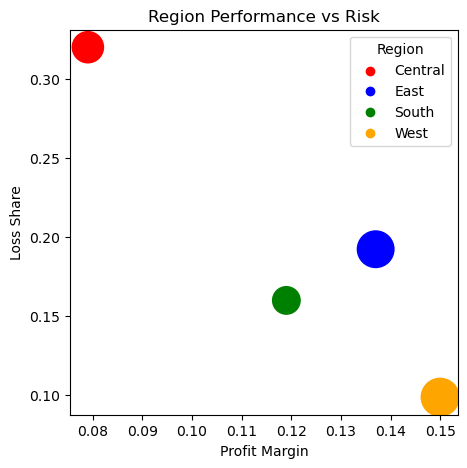

In [870]:
viz_region = summary_region.plot.scatter(
    x='Profit Margin',
    y='Loss_Share',
    s=summary_region['Sales'] / 1000,
    c=['red', 'blue', 'green','orange'],
    figsize=(5,5)
)

viz_region.set_title('Region Performance vs Risk')
viz_region.set_xlabel('Profit Margin')
viz_region.set_ylabel('Loss Share')

viz_region.scatter([], [], color='red', label='Central')
viz_region.scatter([], [], color='blue', label='East')
viz_region.scatter([], [], color='green', label='South')
viz_region.scatter([], [], color='orange', label='West')

viz_region.legend(title='Region')

In [780]:
summary_segment

,Sales,Profit,Profit Margin,Total_Orders,Total_Loss,Loss_Share
Segment,,,,,,
Consumer,1170659.787,136371.446,0.116,2628,-85301.0749,0.192767
Corporate,715806.135,94249.640,0.132,1552,-44934.3022,0.181877
Home Office,440068.432,61675.728,0.140,931,-26803.5531,0.176083


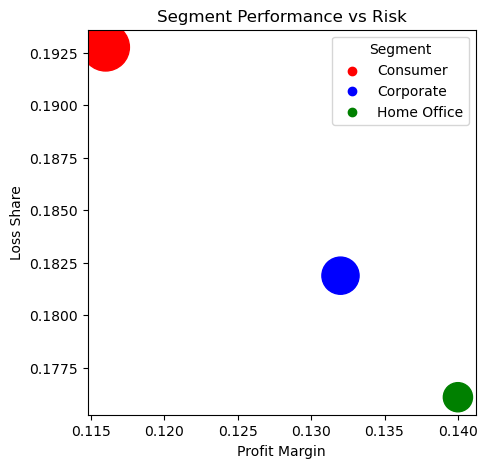

In [880]:
viz_segment = summary_segment.plot.scatter(
    x='Profit Margin',
    y='Loss_Share',
    s=summary_segment['Sales'] / 1000,
    c=['red', 'blue', 'green',],
    figsize=(5,5)
)

viz_segment.set_title('Segment Performance vs Risk')
viz_segment.set_xlabel('Profit Margin')
viz_segment.set_ylabel('Loss Share')

viz_segment.scatter([], [], color='red', label='Consumer')
viz_segment.scatter([], [], color='blue', label='Corporate')
viz_segment.scatter([], [], color='green', label='Home Office')

viz_segment.legend(title='Segment')

In [778]:
summary_category

,Sales,Profit,Profit Margin,Total_Orders,Total_Loss,Loss_Share
Category,,,,,,
Furniture,754747.761,19729.996,0.026,1819,-61675.1837,0.332576
Office Supplies,731893.314,126023.443,0.172,3812,-56783.8283,0.146540
Technology,839893.279,146543.376,0.174,1560,-38579.9182,0.145308


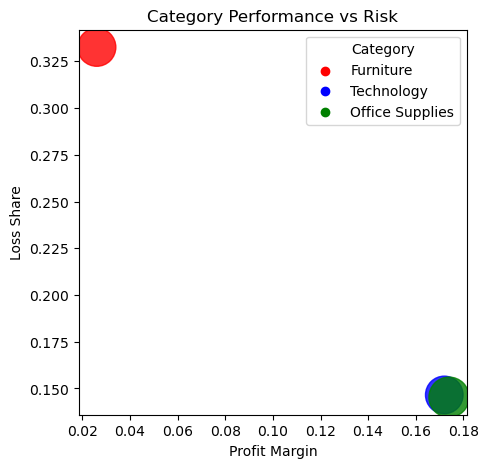

In [872]:
viz_category = summary_category.plot.scatter(
    x='Profit Margin',
    y='Loss_Share',
    s=summary_category['Sales'] / 1000,
    c=['red', 'blue', 'green',],
    figsize=(5,5),
    alpha=0.8
)

viz_category.set_title('Category Performance vs Risk')
viz_category.set_xlabel('Profit Margin')
viz_category.set_ylabel('Loss Share')

viz_category.scatter([], [], color='red', label='Furniture')
viz_category.scatter([], [], color='blue', label='Technology')
viz_category.scatter([], [], color='green', label='Office Supplies')

viz_category.legend(title='Category')

# Part 3. Discount Impact & Profitability Analysis

## Objective 
Understand how discount levels affect profitability and identify the discount threshold where margins turn negative.

## Tasks
1. Create discount buckets to segment transactions by discount level
2. Calculate Total Sales, Total Profit, Profit Margin, and percentage of negative transcactions among the buckets
3. Find the correlation between Discount and Profit

## Discount Buckets

In [969]:
orders['Bucket']=pd.cut(orders['Discount'], bins=[-0.00001,0,0.2,0.5,0.8],
    labels=['0', '(0–0.2]', '(0.2–0.5]', '(0.5–0.8]'],
    right=True)
orders[['Order ID','Discount','Bucket']]

,Order ID,Discount,Bucket
0,US-2022-103800,0.2,(0–0.2]
1,US-2022-112326,0.8,(0.5–0.8]
2,US-2022-112326,0.2,(0–0.2]
3,US-2022-112326,0.2,(0–0.2]
4,US-2022-141817,0.2,(0–0.2]
...,...,...,...
10189,US-2025-143259,0.2,(0–0.2]
10190,US-2025-115427,0.2,(0–0.2]
10191,US-2025-156720,0.2,(0–0.2]
10192,US-2025-143259,0.0,0


## Profitability KPI's by Discount Buckets

In [1027]:
bucket_pivot=pd.pivot_table(
    orders,
    index='Bucket',
    values=['Sales', 'Profit', 'is_loss'],
    aggfunc={
        'Sales': 'sum',
        'Profit': 'sum',
        'is_loss': 'mean'
    })
bucket_pivot = bucket_pivot.rename(columns={'is_loss': 'pct_negative'})
bucket_pivot['pct_negative']=(bucket_pivot['pct_negative']*100)

In [1029]:
bucket_pivot['Margin']=bucket_pivot['Profit']/bucket_pivot['Sales']

In [1031]:
bucket_pivot.round(2)

,Profit,Sales,pct_negative,Margin
Bucket,,,,
0,326718.59,1105323.79,0.00,0.30
(0–0.2],101598.91,856450.41,13.78,0.12
(0.2–0.5],-58990.50,299868.80,91.68,-0.20
(0.5–0.8],-77030.19,64891.35,100.00,-1.19


## Discount vs Profit Correlation

In [1070]:
correlation=orders['Discount'].corr(orders['Profit']).round(2)
print(f'According to Pearson linear correlation it is equal to {correlation}')

According to Pearson linear correlation it is equal to -0.22


## Summary. Part 3

# Part 4. Sub-Category Profitability Deep Dive

## Objective
Identify specific product-level drivers of losses and profitability at the sub-category level.

## Tasks
1. Calculate KPI by Sub-Category:
2. Identify:
    Most profitable sub-categories
    Most loss-making sub-categories
    Sub-categories with high loss frequency
3. Compare:
    Profit contribution vs Sales contribution
    Margin dispersion across sub-categories
4. Conduct a Pareto (80/20) analysis to evaluate the concentration of total profit across sub-categories.

## Sub-Category Overview

In [1275]:
subcat_pivot=pd.pivot_table(
    orders,
    index='Sub-Category',
    values=['Sales', 'Profit', 'is_loss'],
    aggfunc={
        'Sales': 'sum',
        'Profit': 'sum',
        'is_loss': 'mean'
    })
subcat_pivot = subcat_pivot.rename(columns={'is_loss': 'pct_negative'})

In [1277]:
subcat_pivot['Margin']=subcat_pivot['Profit']/subcat_pivot['Sales']
subcat_pivot['Profit_share']=subcat_pivot['Profit']/orders['Profit'].sum()
subcat_pivot['Sales_share']=subcat_pivot['Sales']/orders['Sales'].sum()

In [1279]:
subcat_pivot.round(3)

,Profit,Sales,pct_negative,Margin,Profit_share,Sales_share
Sub-Category,,,,,,
Accessories,41936.636,167380.318,0.117,0.251,0.143,0.072
Appliances,18329.484,108213.185,0.141,0.169,0.063,0.047
Art,6653.196,27659.014,0.001,0.241,0.023,0.012
Binders,31426.100,207354.881,0.400,0.152,0.108,0.089
Bookcases,-3632.074,115361.204,0.478,-0.031,-0.012,0.050
Chairs,27223.532,335768.249,0.375,0.081,0.093,0.144
Copiers,56093.936,150745.290,0.000,0.372,0.192,0.065
Envelopes,6988.025,16528.362,0.000,0.423,0.024,0.007
Fasteners,2428.636,8532.240,0.052,0.285,0.008,0.004


## Loss-Making Sub-Categories Analysis

In [1283]:
top3_profit_subcat=subcat_pivot.sort_values('Profit', ascending=False).head(3).round(2)
top3_profit_subcat

,Profit,Sales,pct_negative,Margin,Profit_share,Sales_share
Sub-Category,,,,,,
Copiers,56093.94,150745.29,0.00,0.37,0.19,0.06
Phones,45050.83,331842.64,0.15,0.14,0.15,0.14
Accessories,41936.64,167380.32,0.12,0.25,0.14,0.07


In [1285]:
top3_loss_subcat=subcat_pivot.sort_values('Profit', ascending=True).head(3).round(2)
top3_loss_subcat

,Profit,Sales,pct_negative,Margin,Profit_share,Sales_share
Sub-Category,,,,,,
Tables,-17753.21,208020.18,0.63,-0.09,-0.06,0.09
Bookcases,-3632.07,115361.20,0.48,-0.03,-0.01,0.05
Supplies,-1171.39,46725.50,0.17,-0.03,-0.00,0.02


In [1287]:
top3_losspct_subcat=subcat_pivot.sort_values('pct_negative', ascending=False).head(3).round(2)
top3_losspct_subcat

,Profit,Sales,pct_negative,Margin,Profit_share,Sales_share
Sub-Category,,,,,,
Tables,-17753.21,208020.18,0.63,-0.09,-0.06,0.09
Bookcases,-3632.07,115361.20,0.48,-0.03,-0.01,0.05
Binders,31426.10,207354.88,0.40,0.15,0.11,0.09


## Efficiency Analysis

In [1290]:
efficient_subcat=subcat_pivot[subcat_pivot['Profit_share']>subcat_pivot['Sales_share']]
efficient_subcat

,Profit,Sales,pct_negative,Margin,Profit_share,Sales_share
Sub-Category,,,,,,
Accessories,41936.6357,167380.318,0.117419,0.250547,0.143473,0.071944
Appliances,18329.4844,108213.185,0.141350,0.169383,0.062708,0.046513
Art,6653.1962,27659.014,0.001218,0.240544,0.022762,0.011889
Binders,31426.1003,207354.881,0.399871,0.151557,0.107514,0.089126
Copiers,56093.9365,150745.290,0.000000,0.372111,0.191907,0.064794
Envelopes,6988.0247,16528.362,0.000000,0.422790,0.023907,0.007104
Fasteners,2428.6358,8532.240,0.052402,0.284642,0.008309,0.003667
Furnishings,13891.7430,95598.126,0.176412,0.145314,0.047526,0.041090
Labels,5572.7780,12695.042,0.005435,0.438973,0.019065,0.005457


In [1292]:
not_efficient_subcat=subcat_pivot[subcat_pivot['Profit_share']<subcat_pivot['Sales_share']]
not_efficient_subcat

,Profit,Sales,pct_negative,Margin,Profit_share,Sales_share
Sub-Category,,,,,,
Bookcases,-3632.0736,115361.2043,0.478448,-0.031484,-0.012426,0.049585
Chairs,27223.5323,335768.2490,0.375394,0.081078,0.093137,0.144321
Machines,3461.9769,189925.0310,0.376068,0.018228,0.011844,0.081634
Storage,21285.1115,224644.5540,0.190421,0.094750,0.072820,0.096558
Supplies,-1171.3945,46725.4980,0.171875,-0.025070,-0.004008,0.020084
Tables,-17753.2061,208020.1820,0.628834,-0.085344,-0.060737,0.089412


In [1294]:
margin_std_subcat=subcat_pivot['Margin'].std()
margin_std_subcat

0.1679618621924883

In [1296]:
margindiff_subcat=subcat_pivot['Margin'].max() - subcat_pivot['Margin'].min()

## Pareto Analysis

In [1301]:
subcat_pivot=subcat_pivot.sort_values('Profit', ascending=False)
subcat_pivot['Profit_share_subcat']=(subcat_pivot['Profit'] / subcat_pivot['Profit'].sum())
subcat_pivot['Cumulative_profit_%'] = (subcat_pivot['Profit_share'].cumsum() * 100)
subcat_pivot

,Profit,Sales,pct_negative,Margin,Profit_share,Sales_share,Profit_share_subcat,Cumulative_profit_%
Sub-Category,,,,,,,,
Copiers,56093.9365,150745.2900,0.000000,0.372111,0.191907,0.064794,0.191907,19.190745
Phones,45050.8265,331842.6400,0.150609,0.135760,0.154127,0.142634,0.154127,34.603443
Accessories,41936.6357,167380.3180,0.117419,0.250547,0.143473,0.071944,0.143473,48.950721
Paper,34511.5070,79540.5380,0.000723,0.433886,0.118070,0.034188,0.118070,60.757729
Binders,31426.1003,207354.8810,0.399871,0.151557,0.107514,0.089126,0.107514,71.509163
Chairs,27223.5323,335768.2490,0.375394,0.081078,0.093137,0.144321,0.093137,80.822823
Storage,21285.1115,224644.5540,0.190421,0.094750,0.072820,0.096558,0.072820,88.104843
Appliances,18329.4844,108213.1850,0.141350,0.169383,0.062708,0.046513,0.062708,94.375690
Furnishings,13891.7430,95598.1260,0.176412,0.145314,0.047526,0.041090,0.047526,99.128305


In [1303]:
top80_pct=subcat_pivot[subcat_pivot['Cumulative_profit_%']<=85]
top80_pct

,Profit,Sales,pct_negative,Margin,Profit_share,Sales_share,Profit_share_subcat,Cumulative_profit_%
Sub-Category,,,,,,,,
Copiers,56093.9365,150745.290,0.000000,0.372111,0.191907,0.064794,0.191907,19.190745
Phones,45050.8265,331842.640,0.150609,0.135760,0.154127,0.142634,0.154127,34.603443
Accessories,41936.6357,167380.318,0.117419,0.250547,0.143473,0.071944,0.143473,48.950721
Paper,34511.5070,79540.538,0.000723,0.433886,0.118070,0.034188,0.118070,60.757729
Binders,31426.1003,207354.881,0.399871,0.151557,0.107514,0.089126,0.107514,71.509163
Chairs,27223.5323,335768.249,0.375394,0.081078,0.093137,0.144321,0.093137,80.822823


## Summary. Part 4

# Part 5. Customer Analytics

## Objective
Customer Segmentation

## Tasks
1. Calculate Customer-level KPIs
2. Find Top-10 & loss-making customers
3. Create RFM Sefmentation
4. Analyze Segment vs Profitability relationship

## Customer-level KPIs

In [1371]:
customer_pivot=pd.pivot_table(
    orders,
    index='Customer Name',
    values=['Sales', 'Profit','Discount','Order ID'],
    aggfunc={
        'Sales': 'sum',
        'Profit': 'sum',
        'Discount': 'mean',
        'Order ID': 'nunique'})
customer_pivot = customer_pivot.rename(
    columns={'Order ID': 'Orders Count'}
)
customer_pivot = customer_pivot[['Sales', 'Profit', 'Orders Count', 'Discount']]
customer_pivot.round(3)

,Sales,Profit,Orders Count,Discount
Customer Name,,,,
Aaron Bergman,886.156,129.346,3,0.067
Aaron Hawkins,1744.700,365.215,7,0.091
Aaron Smayling,3050.692,-253.575,7,0.355
Adam Bellavance,7755.620,2054.588,8,0.044
Adam Hart,3250.337,281.189,10,0.135
...,...,...,...,...
Xylona Preis,2503.156,675.958,13,0.044
Yana Sorensen,6720.444,1778.292,8,0.050
Yoseph Carroll,5454.350,1305.629,5,0.075


## Top-10 loss-making clients

In [1381]:
top10_profit_customers=customer_pivot.sort_values('Profit', ascending=False).head(10).round(2)
top10_profit_customers

,Sales,Profit,Orders Count,Discount
Customer Name,,,,
Tamara Chand,19052.22,8981.32,5,0.12
Raymond Buch,15117.34,6976.10,6,0.09
Sanjit Chand,14142.33,5757.41,9,0.06
Hunter Lopez,12873.30,5622.43,6,0.02
Adrian Barton,14473.57,5444.81,10,0.24
Tom Ashbrook,14595.62,4703.79,4,0.08
Christopher Martinez,8954.02,3899.89,4,0.12
Keith Dawkins,8181.26,3038.63,12,0.09
Andy Reiter,6608.45,2884.62,6,0.07


In [1398]:
neg_profit_customers=customer_pivot[customer_pivot['Profit']<0]
neg_profit_customers=neg_profit_customers.sort_values('Profit', ascending=True).round(2)
neg_profit_customers

,Sales,Profit,Orders Count,Discount
Customer Name,,,,
Cindy Stewart,5690.06,-6626.39,6,0.20
Grant Thornton,9351.21,-4108.66,3,0.25
Luke Foster,3930.51,-3583.98,7,0.32
Sharelle Roach,3233.48,-3333.91,5,0.37
Henry Goldwyn,3247.64,-2797.96,12,0.17
...,...,...,...,...
Thais Sissman,4.83,-3.32,2,0.70
Adrian Hane,1735.51,-2.31,7,0.24
Mitch Gastineau,16.74,-1.25,1,0.45


In [1416]:
pct_negative_customers = ((customer_pivot['Profit'] < 0).sum()
    / orders['Customer Name'].nunique()) * 100
pct_negative_customers

19.75

## RFM Segmentation

In [1420]:
reference_date = orders['Order Date'].max()
recency = (
    reference_date - 
    orders.groupby('Customer Name')['Order Date'].max()
).dt.days
recency

Customer Name
Aaron Bergman         415
Aaron Hawkins          12
Aaron Smayling         88
Adam Bellavance        54
Adam Hart              34
                     ... 
Xylona Preis           43
Yana Sorensen           9
Yoseph Carroll          4
Zuschuss Carroll       54
Zuschuss Donatelli    202
Name: Order Date, Length: 800, dtype: int64

In [1424]:
frequency = orders.groupby('Customer Name')['Order ID'].nunique()
frequency

Customer Name
Aaron Bergman          3
Aaron Hawkins          7
Aaron Smayling         7
Adam Bellavance        8
Adam Hart             10
                      ..
Xylona Preis          13
Yana Sorensen          8
Yoseph Carroll         5
Zuschuss Carroll      13
Zuschuss Donatelli     5
Name: Order ID, Length: 800, dtype: int64

In [1428]:
monetary = orders.groupby('Customer Name')['Profit'].sum()
monetary

Customer Name
Aaron Bergman          129.3465
Aaron Hawkins          365.2152
Aaron Smayling        -253.5746
Adam Bellavance       2054.5885
Adam Hart              281.1890
                        ...    
Xylona Preis           675.9584
Yana Sorensen         1778.2923
Yoseph Carroll        1305.6290
Zuschuss Carroll     -1032.1490
Zuschuss Donatelli     249.1307
Name: Profit, Length: 800, dtype: float64

In [1448]:
rfm = pd.concat([recency, frequency, monetary], axis=1)
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm

,Recency,Frequency,Monetary
Customer Name,,,
Aaron Bergman,415,3,129.3465
Aaron Hawkins,12,7,365.2152
Aaron Smayling,88,7,-253.5746
Adam Bellavance,54,8,2054.5885
Adam Hart,34,10,281.1890
...,...,...,...
Xylona Preis,43,13,675.9584
Yana Sorensen,9,8,1778.2923
Yoseph Carroll,4,5,1305.6290


In [1460]:
rfm['R_score'] = pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'),5,labels=[1,2,3,4,5])

In [1474]:
rfm['RFM_score'] = (rfm['R_score'].astype(int) + rfm['F_score'].astype(int) + rfm['M_score'].astype(int))
rfm.sort_values('RFM_score', ascending=False)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
Customer Name,,,,,,,
Annie Thurman,13,10,974.1070,5,5,5,15
Arianne Irving,13,10,867.7271,5,5,5,15
James Galang,1,11,1415.6664,5,5,5,15
Harry Marie,2,10,2437.9836,5,5,5,15
Chris Selesnick,26,12,738.3626,5,5,5,15
...,...,...,...,...,...,...,...
Pauline Chand,882,2,-184.3364,1,1,1,3
Becky Martin,307,4,-1659.9581,1,1,1,3
Harold Dahlen,769,3,-135.8760,1,1,1,3


In [1506]:
def segment_customer(row):
    if row['RFM_score'] >= 12:
        return 'High Value'
    elif row['RFM_score'] >= 9:
        return 'Loyal'
    elif row['RFM_score'] >= 4:
        return 'At Risk'
    else:
        return 'Low Value '
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [1508]:
rfm.sort_values('RFM_score', ascending=False)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
Customer Name,,,,,,,,
Annie Thurman,13,10,974.1070,5,5,5,15,High Value
Arianne Irving,13,10,867.7271,5,5,5,15,High Value
James Galang,1,11,1415.6664,5,5,5,15,High Value
Harry Marie,2,10,2437.9836,5,5,5,15,High Value
Chris Selesnick,26,12,738.3626,5,5,5,15,High Value
...,...,...,...,...,...,...,...,...
Pauline Chand,882,2,-184.3364,1,1,1,3,Low Value
Becky Martin,307,4,-1659.9581,1,1,1,3,Low Value
Harold Dahlen,769,3,-135.8760,1,1,1,3,Low Value


## Profitability by Customer Segment

In [1579]:
segment_profit = rfm.merge(
    customer_pivot[['Sales','Profit']],
    left_index=True,
    right_index=True)

segment_agg = segment_profit.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum'})

segment_agg['Margin'] = (segment_agg['Profit'] / segment_agg['Sales'])

segment_agg['Profit_share_%'] = (segment_agg['Profit'] / segment_agg['Profit'].sum() * 100).round(2)

segment_agg['Avg_Profit_per_Customer'] = (segment_profit.groupby('Segment')['Profit'].mean())

segment_agg

,Sales,Profit,Margin,Profit_share_%,Avg_Profit_per_Customer
Segment,,,,,
At Risk,578818.4027,9102.7986,0.015727,3.11,28.446246
High Value,878437.8795,166284.3778,0.189296,56.89,875.180936
Low Value,35885.4335,-6749.9234,-0.188096,-2.31,-249.997163
Loyal,833392.6386,123659.5616,0.148381,42.31,470.188447


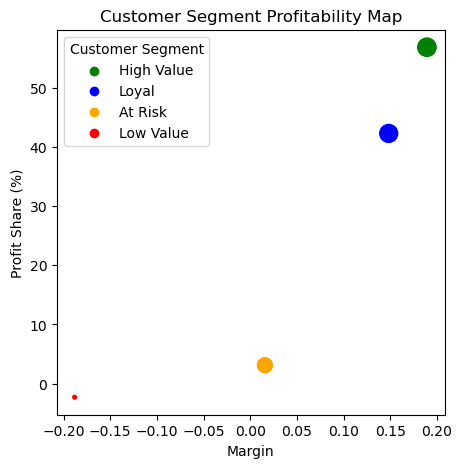

In [1595]:
viz_customer_segment = segment_agg.plot.scatter(
    x='Margin',
    y='Profit_share_%',
    s=segment_agg['Sales'] / 5000,
    c=['orange', 'green', 'red', 'blue'],
    figsize=(5,5)
)

viz_customer_segment.set_title('Customer Segment Profitability Map')
viz_customer_segment.set_xlabel('Margin')
viz_customer_segment.set_ylabel('Profit Share (%)')

viz_customer_segment.scatter([], [], color='green', label='High Value')
viz_customer_segment.scatter([], [], color='blue', label='Loyal')
viz_customer_segment.scatter([], [], color='orange', label='At Risk')
viz_customer_segment.scatter([], [], color='red', label='Low Value')

viz_customer_segment.legend(title='Customer Segment')

## Summary. Part 5

# Part 6. Time Series & Trend Analysis

## Objective
Analyze business performance dynamics over time.

## Tasks
1. Build: Monthly Sales, Monthly Profit, Monthly Margin
2. Calculate: Month-over-Month (MoM) growth and Year-over-Year (YoY) growth
3. Identify seasonality patterns.




## Monthly Sales, Monthly Profit, Monthly Margin

In [1649]:
orders['Year_Month'] = orders['Order Date'].dt.to_period('M')

In [1651]:
monthly = orders.groupby('Year_Month').agg({
    'Sales': 'sum',
    'Profit': 'sum'
})

monthly['Margin'] = monthly['Profit'] / monthly['Sales']

monthly.index = monthly.index.to_timestamp()

In [1739]:
correlation = monthly['Sales'].corr(monthly['Profit']).round(2)
print(f'The Pearson linear correlation coefficient shows a strong positive correlation of {correlation}')

The Pearson linear correlation coefficient shows a strong positive correlation of 0.72


Text(0, 0.5, 'Value')

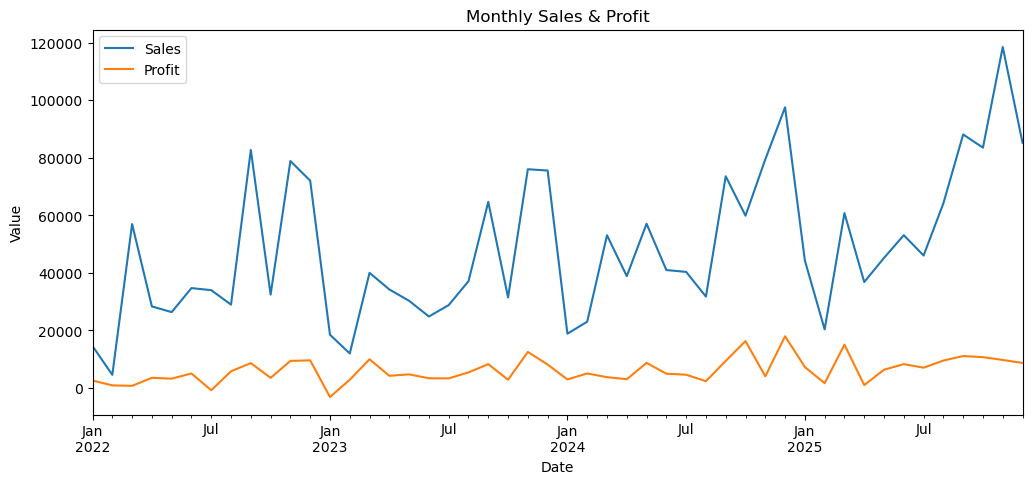

In [1732]:
viz_monthly = monthly[['Sales','Profit']].plot( 
    figsize=(12,5), 
    title='Monthly Sales & Profit') 

viz_monthly.set_xlabel('Date') 
viz_monthly.set_ylabel('Value')

Text(0, 0.5, 'Margin (%)')

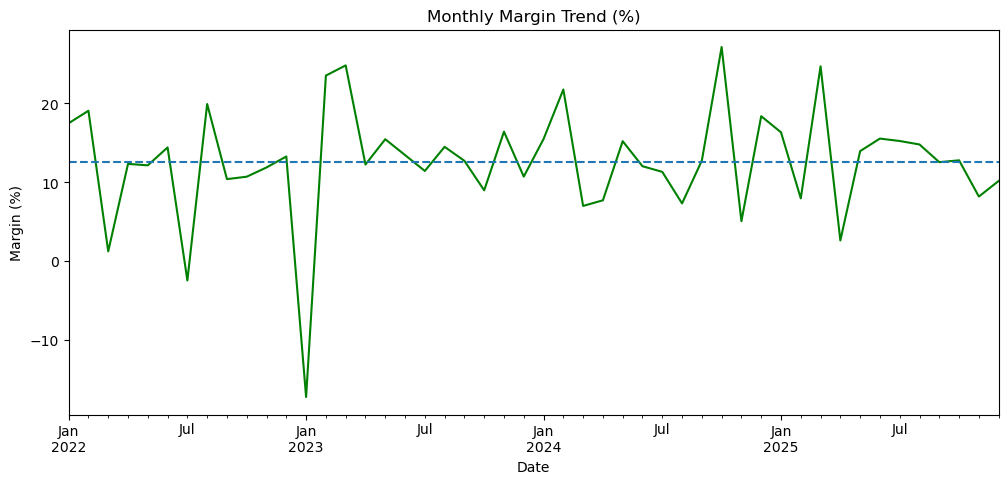

In [1655]:
viz_monthly_margin = (monthly['Margin'] * 100).plot(
    figsize=(12,5),
    title='Monthly Margin Trend (%)',
    color='green'
)

viz_monthly_margin.axhline(
    y=monthly['Margin'].mean() * 100,
    linestyle='--'
)

viz_monthly_margin.set_xlabel('Date')
viz_monthly_margin.set_ylabel('Margin (%)')

In [1710]:
margin_mean = monthly['Margin'].mean()
margin_std = monthly['Margin'].std()

anomalies = monthly[monthly['Margin'] < (margin_mean - 2 * margin_std)]
anomalies

,Sales,Profit,Margin,MoM_Sales_%,MoM_Profit_%,YoY_Sales_%,YoY_Profit_%
Year_Month,,,,,,,
2022-07-01,33946.3930,-841.4826,-0.024789,-2.09,-116.83,NaN,NaN
2023-01-01,18461.9156,-3189.8030,-0.172777,-74.36,-133.38,27.17,-225.61


## MoM and YoY growth

In [1660]:
monthly['MoM_Sales_%'] = (monthly['Sales'].pct_change() * 100).round(2)
monthly['MoM_Profit_%'] = (monthly['Profit'].pct_change() * 100).round(2)

In [1664]:
monthly['YoY_Sales_%'] = (monthly['Sales'].pct_change(12) * 100).round(2)
monthly['YoY_Profit_%'] = (monthly['Profit'].pct_change(12) * 100).round(2)

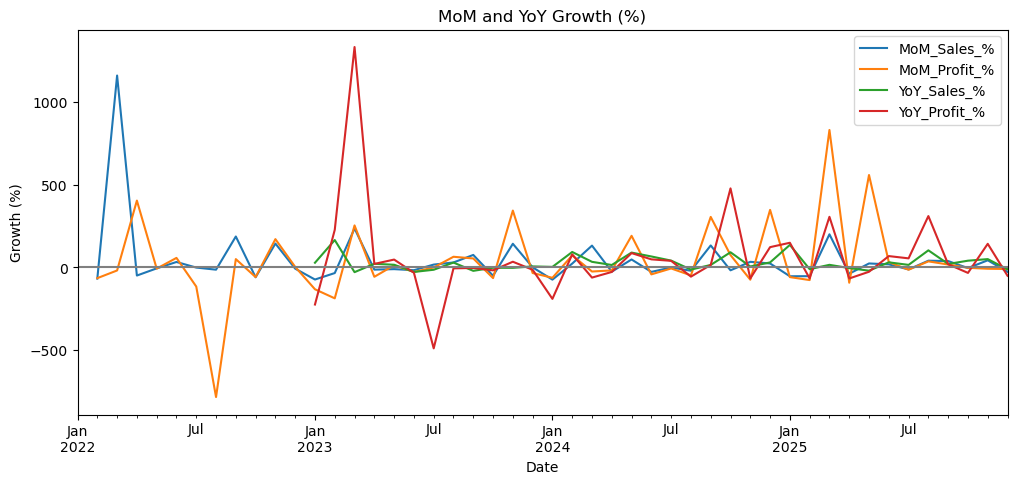

In [1684]:
viz_monthly_sum = monthly[
    ['MoM_Sales_%',
     'MoM_Profit_%',
     'YoY_Sales_%',
     'YoY_Profit_%']
].plot(
    figsize=(12,5),
    title='MoM and YoY Growth (%)'
)

viz_monthly_sum.set_xlabel('Date')
viz_monthly_sum.set_ylabel('Growth (%)')
viz_monthly_sum.axhline(0, linestyle='-',c='grey')

## Seasonality patterns

In [1687]:
orders['Month'] = orders['Order Date'].dt.month
seasonality = orders.groupby('Month').agg({'Sales': 'mean','Profit': 'mean'})
seasonality['Margin'] = seasonality['Profit'] / seasonality['Sales']

Text(0, 0.5, 'Average Sales')

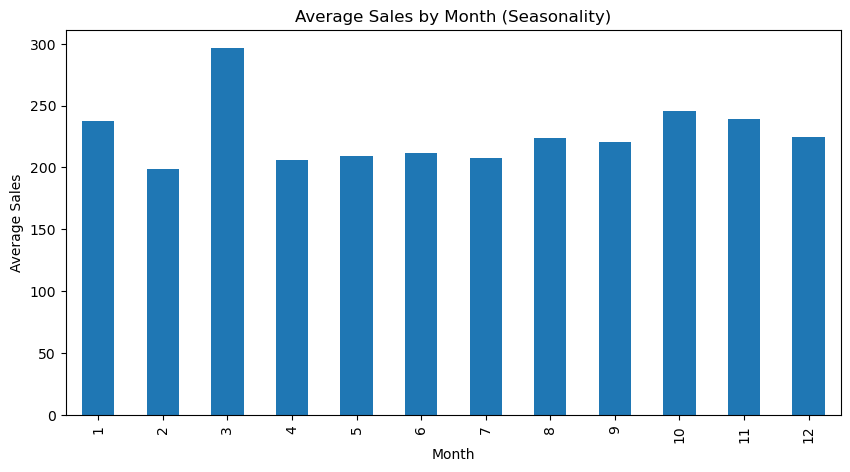

In [1689]:
viz_seasonality = seasonality['Sales'].plot(
    kind='bar',
    figsize=(10,5),
    title='Average Sales by Month (Seasonality)'
)

viz_seasonality.set_xlabel('Month')
viz_seasonality.set_ylabel('Average Sales')

## Summary. Part 6

# Part 7. Shipping & Operational Efficiency

## Objective
Assess the impact of logistics on profitability.

## Tasks
1. Calculate average shipping days by region and shipping mode
2. Analyze shipping days vs profit and return rate
3. Identify the most expensive and the most profitable shipping method
4. Determine whether faster delivery impacts profitability.

## Average shipping days by region and shipping mode

In [1789]:
avg_ship = (
    orders
        .groupby(['Region', 'Ship Mode'])['ship_days']
        .mean()
        .to_frame('avg_ship_days')
        .groupby(level=0, group_keys=False)
        .apply(lambda x: x.sort_values('avg_ship_days', ascending=True))
).round(2)

avg_ship

avg_ship_days
Region  Ship Mode                    
Central Same Day                 0.03
        First Class              2.31
        Second Class             3.33
        Standard Class           4.98
East    Same Day                 0.00
        First Class              2.23
        Second Class             3.24
        Standard Class           4.94
South   Same Day                 0.01
        First Class              2.11
        Second Class             3.19
        Standard Class           5.00
West    Same Day                 0.10
        First Class              2.10
        Second Class             3.19
        Standard Class           5.05

## Shipping days vs profit and return rate

In [1935]:
ship_profit = (orders.groupby('ship_days')['Profit'].mean()).to_frame('Avg_Profit').round(3)
ship_profit

,Avg_Profit
ship_days,
0,29.933
1,20.437
2,39.580
3,26.522
4,25.274
5,27.876
6,27.661
7,32.488
11,35.414


In [1937]:
orders = (orders.merge(returns[['Order ID']],on='Order ID',how='left',indicator=True))
orders['is_returned'] = (orders['_merge'] == 'both').astype(int)
orders.drop(columns=['_merge'], inplace=True)

In [1943]:
return_by_days = (orders.groupby('ship_days')['returned_flag'].mean()).to_frame('Return Rate').round(3)
return_by_days

,Return Rate
ship_days,
0,0.122
1,0.092
2,0.074
3,0.096
4,0.071
5,0.062
6,0.088
7,0.092
11,0.000


## The most expensive and the most profitable shipping method

In [1929]:
sales_by_shipmode = (orders.groupby('Ship Mode')['Sales'].mean()).round(3).to_frame('Avg Sales')
sales_by_shipmode

,Avg Sales
Ship Mode,
First Class,227.229
Same Day,236.329
Second Class,235.812
Standard Class,225.301


In [1923]:
profit_by_shipmode = (orders.groupby('Ship Mode')['Profit'].mean()).to_frame('Avg Profit').round(3)
profit_by_shipmode

,Avg Profit
Ship Mode,
First Class,31.662
Same Day,29.544
Second Class,29.794
Standard Class,27.477


## Faster delivery vs profitability

In [1919]:
orders['ship_days'].corr(orders['Profit']).round(3)

-0.004

In [1913]:
profit_by_days = (orders.groupby('ship_days')['Profit'].mean().to_frame('Avg_Profit').round(3))

profit_by_days

,Avg_Profit
ship_days,
0,29.933
1,20.437
2,39.580
3,26.522
4,25.274
5,27.876
6,27.661
7,32.488
11,35.414


In [1917]:
median_days = orders['ship_days'].median()

orders['speed_group'] = orders['ship_days'].apply(lambda x: 'Fast' if x <= median_days else 'Slow')

profit_by_speed_groups=orders.groupby('speed_group')['Profit'].mean().to_frame('Avg Profit').round(3)
profit_by_speed_groups

,Avg Profit
speed_group,
Fast,28.769
Slow,28.529


## Summary. Part 7

# Part 8. Cohort & Retention Analysis

## Objective
Understand customer retention dynamics and revenue longevity.


## Tasks
1. Define acquisition cohort
2. Build retention matrix
3. Calculate the  Revenue Retention
4. Find a Cohort cumulative profit

## Acquisition  cohort

In [2098]:
orders['Order_Period'] = orders['Order Date'].dt.to_period('M')

In [2100]:
orders['Cohort_Period'] = (
    orders
    .groupby('Customer Name')['Order_Period']
    .transform('min'))

In [2102]:
orders['Cohort_Index'] = (
    (orders['Order_Period'].dt.year - orders['Cohort_Period'].dt.year) * 12 
    +
    (orders['Order_Period'].dt.month - orders['Cohort_Period'].dt.month))

In [2108]:
orders[['Customer Name',
        'Order Date',
        'Order_Period',
        'Cohort_Period',
        'Cohort_Index']].sort_values(['Customer Name','Order Date'])

,Customer Name,Order Date,Order_Period,Cohort_Period,Cohort_Index
119,Aaron Bergman,2022-02-18,2022-02,2022-02,0
161,Aaron Bergman,2022-03-07,2022-03,2022-02,1
164,Aaron Bergman,2022-03-07,2022-03,2022-02,1
167,Aaron Bergman,2022-03-07,2022-03,2022-02,1
6175,Aaron Bergman,2024-11-10,2024-11,2022-02,33
...,...,...,...,...,...
4546,Zuschuss Donatelli,2024-04-03,2024-04,2022-08,20
4723,Zuschuss Donatelli,2024-05-05,2024-05,2022-08,21
5174,Zuschuss Donatelli,2024-07-08,2024-07,2022-08,23
5177,Zuschuss Donatelli,2024-07-08,2024-07,2022-08,23


## Retention Matrix

In [2120]:
cohort_counts = (
    orders
    .groupby(['Cohort_Period', 'Cohort_Index'])['Customer Name']
    .nunique()
    .to_frame('Active Customers'))
cohort_counts

Active Customers
Cohort_Period Cohort_Index                  
2022-01       0                           33
              1                            3
              3                            2
              4                            2
              6                            2
...                                      ...
2025-07       0                            2
              5                            1
2025-09       0                            1
2025-10       0                            2
2025-11       0                            1

[893 rows x 1 columns]

In [2124]:
cohort_matrix = cohort_counts['Active Customers'].unstack(fill_value=0)
cohort_matrix

Cohort_Index,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
Cohort_Period,,,,,,,,,,,,,,,,,,,,,
2022-01,33,3,0,2,2,0,2,4,5,3,...,6,4,5,4,1,2,9,10,11,6
2022-02,24,4,2,1,0,2,2,3,3,4,...,2,2,5,3,3,4,6,6,3,0
2022-03,66,5,2,8,7,0,8,5,8,6,...,13,10,12,7,20,8,18,16,0,0
2022-04,55,6,2,4,3,7,6,9,8,1,...,5,7,7,14,8,15,14,0,0,0
2022-05,57,5,5,4,11,2,12,10,4,3,...,7,6,17,8,18,10,0,0,0,0
2022-06,49,1,2,5,2,9,9,1,4,6,...,3,13,7,14,12,0,0,0,0,0
2022-07,44,6,5,0,5,8,2,0,8,2,...,11,10,13,9,0,0,0,0,0,0
2022-08,52,9,3,11,5,3,4,2,4,4,...,13,13,12,0,0,0,0,0,0,0
2022-09,68,9,9,12,1,2,9,10,8,2,...,15,11,0,0,0,0,0,0,0,0


In [2134]:
cohort_sizes = cohort_matrix[0]
retention = (cohort_matrix.div(cohort_sizes, axis=0)*100).round(1)
retention

Cohort_Index,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
Cohort_Period,,,,,,,,,,,,,,,,,,,,,
2022-01,100.0,9.1,0.0,6.1,6.1,0.0,6.1,12.1,15.2,9.1,...,18.2,12.1,15.2,12.1,3.0,6.1,27.3,30.3,33.3,18.2
2022-02,100.0,16.7,8.3,4.2,0.0,8.3,8.3,12.5,12.5,16.7,...,8.3,8.3,20.8,12.5,12.5,16.7,25.0,25.0,12.5,0.0
2022-03,100.0,7.6,3.0,12.1,10.6,0.0,12.1,7.6,12.1,9.1,...,19.7,15.2,18.2,10.6,30.3,12.1,27.3,24.2,0.0,0.0
2022-04,100.0,10.9,3.6,7.3,5.5,12.7,10.9,16.4,14.5,1.8,...,9.1,12.7,12.7,25.5,14.5,27.3,25.5,0.0,0.0,0.0
2022-05,100.0,8.8,8.8,7.0,19.3,3.5,21.1,17.5,7.0,5.3,...,12.3,10.5,29.8,14.0,31.6,17.5,0.0,0.0,0.0,0.0
2022-06,100.0,2.0,4.1,10.2,4.1,18.4,18.4,2.0,8.2,12.2,...,6.1,26.5,14.3,28.6,24.5,0.0,0.0,0.0,0.0,0.0
2022-07,100.0,13.6,11.4,0.0,11.4,18.2,4.5,0.0,18.2,4.5,...,25.0,22.7,29.5,20.5,0.0,0.0,0.0,0.0,0.0,0.0
2022-08,100.0,17.3,5.8,21.2,9.6,5.8,7.7,3.8,7.7,7.7,...,25.0,25.0,23.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-09,100.0,13.2,13.2,17.6,1.5,2.9,13.2,14.7,11.8,2.9,...,22.1,16.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2193]:
retention_first = retention.head(12).iloc[:, :12]

In [2195]:
retention_first.style.background_gradient(cmap='Blues', vmin=0, vmax=100).format("{:.1f}%")

Cohort_Index,0,1,2,3,4,5,6,7,8,9,10,11
Cohort_Period,,,,,,,,,,,,
2022-01,100.0%,9.1%,0.0%,6.1%,6.1%,0.0%,6.1%,12.1%,15.2%,9.1%,21.2%,15.2%
2022-02,100.0%,16.7%,8.3%,4.2%,0.0%,8.3%,8.3%,12.5%,12.5%,16.7%,16.7%,4.2%
2022-03,100.0%,7.6%,3.0%,12.1%,10.6%,0.0%,12.1%,7.6%,12.1%,9.1%,1.5%,3.0%
2022-04,100.0%,10.9%,3.6%,7.3%,5.5%,12.7%,10.9%,16.4%,14.5%,1.8%,7.3%,7.3%
2022-05,100.0%,8.8%,8.8%,7.0%,19.3%,3.5%,21.1%,17.5%,7.0%,5.3%,8.8%,12.3%
2022-06,100.0%,2.0%,4.1%,10.2%,4.1%,18.4%,18.4%,2.0%,8.2%,12.2%,10.2%,10.2%
2022-07,100.0%,13.6%,11.4%,0.0%,11.4%,18.2%,4.5%,0.0%,18.2%,4.5%,15.9%,15.9%
2022-08,100.0%,17.3%,5.8%,21.2%,9.6%,5.8%,7.7%,3.8%,7.7%,7.7%,9.6%,11.5%
2022-09,100.0%,13.2%,13.2%,17.6%,1.5%,2.9%,13.2%,14.7%,11.8%,2.9%,8.8%,11.8%


## Revenue Retention

In [2173]:
cohort_revenue = (orders.groupby(['Cohort_Period', 'Cohort_Index'])['Sales'].sum().unstack(fill_value=0))

Cohort_Index,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
Cohort_Period,,,,,,,,,,,,,,,,,,,,,
2022-01,14518.0550,225.232,0.000,1472.3820,47.7500,0.000,116.298,907.584,1609.700,1477.6260,...,2788.5840,204.096,1576.309,1960.700,807.898,357.0800,8075.530,7397.253,12337.626,665.12
2022-02,4294.6600,634.310,596.252,576.2340,0.0000,697.386,1040.400,11907.525,3345.146,6347.6400,...,560.6460,159.280,6447.905,782.616,1072.896,996.9020,1571.165,3605.562,604.534,0.00
2022-03,56299.5990,1595.686,2543.338,3298.7236,3101.2180,0.000,2951.612,1833.342,5968.528,2654.7920,...,4769.0484,5709.824,3162.986,3330.668,4859.230,2486.5112,8718.464,6102.418,0.000,0.00
2022-04,24631.0250,2410.624,875.455,2325.4680,454.1520,3104.085,1245.682,6778.990,6230.509,13.3600,...,2420.3280,5826.792,3824.548,6036.309,3210.674,4058.3412,8675.190,0.000,0.000,0.00
2022-05,20741.8210,1685.128,1862.666,653.2600,8755.0190,462.944,10024.595,7146.804,2463.350,748.5760,...,2512.4340,677.482,3365.641,5965.780,11635.599,2500.0400,0.000,0.000,0.000,0.00
2022-06,28810.1730,351.216,31.000,1563.7820,104.1520,5489.491,3299.740,43.660,146.420,649.9720,...,285.3800,6839.413,1804.020,15355.630,3757.876,0.0000,0.000,0.000,0.000,0.00
2022-07,25492.1410,2188.379,1044.661,0.0000,1319.1340,4257.844,2759.794,0.000,4581.381,342.1820,...,2408.2820,7954.193,5918.620,5072.975,0.000,0.0000,0.000,0.000,0.000,0.00
2022-08,23643.5635,8132.190,272.422,3807.4400,1244.3860,4411.208,2586.352,162.496,1060.226,490.3180,...,3863.7320,4553.831,8717.887,0.000,0.000,0.0000,0.000,0.000,0.000,0.00
2022-09,43601.8548,1882.084,3490.648,7936.0065,31.5380,188.862,2850.152,2138.150,5280.584,137.6600,...,4046.4450,4114.138,0.000,0.000,0.000,0.0000,0.000,0.000,0.000,0.00


In [2201]:
cohort_revenue_size = cohort_revenue[0]

In [2203]:
revenue_retention = (cohort_revenue.div(cohort_revenue_size, axis=0)*100).round(1)

In [2221]:
revenue_retention_first=revenue_retention.head(12).iloc[:, :12]

In [2225]:
revenue_retention_first.style.background_gradient(cmap='Greens', vmin=0, vmax=300).format("{:.1f}%")

Cohort_Index,0,1,2,3,4,5,6,7,8,9,10,11
Cohort_Period,,,,,,,,,,,,
2022-01,100.0%,1.6%,0.0%,10.1%,0.3%,0.0%,0.8%,6.3%,11.1%,10.2%,21.6%,78.0%
2022-02,100.0%,14.8%,13.9%,13.4%,0.0%,16.2%,24.2%,277.3%,77.9%,147.8%,5.3%,1.4%
2022-03,100.0%,2.8%,4.5%,5.9%,5.5%,0.0%,5.2%,3.3%,10.6%,4.7%,0.6%,1.1%
2022-04,100.0%,9.8%,3.6%,9.4%,1.8%,12.6%,5.1%,27.5%,25.3%,0.1%,7.7%,0.8%
2022-05,100.0%,8.1%,9.0%,3.1%,42.2%,2.2%,48.3%,34.5%,11.9%,3.6%,17.1%,31.9%
2022-06,100.0%,1.2%,0.1%,5.4%,0.4%,19.1%,11.5%,0.2%,0.5%,2.3%,10.3%,14.3%
2022-07,100.0%,8.6%,4.1%,0.0%,5.2%,16.7%,10.8%,0.0%,18.0%,1.3%,6.9%,3.1%
2022-08,100.0%,34.4%,1.2%,16.1%,5.3%,18.7%,10.9%,0.7%,4.5%,2.1%,12.2%,18.6%
2022-09,100.0%,4.3%,8.0%,18.2%,0.1%,0.4%,6.5%,4.9%,12.1%,0.3%,1.2%,3.0%


## Cohort Cumulative Profit

In [2228]:
cohort_profit = (orders.groupby(['Cohort_Period', 'Cohort_Index'])['Profit'].sum().unstack(fill_value=0))

In [2230]:
cohort_cum_profit = cohort_profit.cumsum(axis=1)

In [2232]:
cohort_cum_profit_first = cohort_cum_profit.head(12).iloc[:, :12]

In [2244]:
cohort_cum_profit_first.style.background_gradient(cmap='Oranges', vmin=-2000, vmax=10000).format("{:,.0f}")

Cohort_Index,0,1,2,3,4,5,6,7,8,9,10,11
Cohort_Period,,,,,,,,,,,,
2022-01,"2,539","2,575","2,575","2,336","2,353","2,353","2,388","2,514","2,894","2,165","2,407","5,448"
2022-02,827,875,"1,057","1,136","1,136","1,172","1,539","7,052","7,534","9,891","9,952","9,945"
2022-03,645,412,526,895,"1,296","1,296","1,840","1,885","2,965","3,059","3,190","3,417"
2022-04,"3,779","4,021","4,205","4,723","4,878","4,003","4,161","5,589","6,791","6,795","7,393","7,457"
2022-05,"2,744","3,210","3,463","3,340","2,063","2,131","3,211","3,935","2,434","2,648","3,328","3,286"
2022-06,"3,981","3,985","4,001","4,452","4,487","4,276","4,478","4,499","4,551","4,620","4,230","5,179"
2022-07,"-2,090","-1,469","-1,368","-1,368","-1,588",-446,7,7,"1,234","1,373","1,669","1,822"
2022-08,"4,606","6,157","6,235","6,868","6,564","4,745","5,041","5,101","5,157","5,207","5,227","5,961"
2022-09,"2,205","2,394","2,571","2,946","2,954","2,910","2,886","3,534","4,077","4,141","4,131","4,495"


## Summary. Part 8

# Part 9. Regional Manager Performance

## Objective
Assess regional manager effectiveness by analyzing sales, profit dynamics, and risk patterns across regions.


## Tasks
1. Provide Profit Stability Analysis
2. Conduct Loss & Risk Analysis
3. Find Revenue Structure & Concentration
4. Calculate Profit Contribution
   

## Profit Stability Analysis

In [2262]:
manager_data = (orders.merge(people, on='Region', how='left'))
manager_data['Year_Month'] = manager_data['Order Date'].dt.to_period('M')
monthly_profit = (manager_data.groupby(['Regional Manager', 'Year_Month'])['Profit'].sum().reset_index())

In [2274]:
manager_stability = (monthly_profit.groupby('Regional Manager')['Profit']
        .agg(
            avg_monthly_profit='mean',
            profit_std='std',
            min_monthly_profit='min',
            max_monthly_profit='max',
            active_months='count')
        .reset_index()).round(2)

In [2272]:
manager_stability

,Regional Manager,avg_monthly_profit,profit_std,min_monthly_profit,max_monthly_profit,active_months
0,Chuck Magee,1976.735,2481.826,-4842.242,9392.257,48
1,Fred Suzuki,973.946,1269.510,-2243.235,4185.061,48
2,Roxanne Rodriguez,830.527,2198.093,-4055.334,10771.451,48
3,Sadie Pawthorne,2308.309,1875.580,-1723.215,9309.765,48


In [2282]:
manager_stability['volatility_ratio'] = (manager_stability['profit_std']/manager_stability['avg_monthly_profit'].abs()).round(3)

In [2284]:
manager_stability

,Regional Manager,avg_monthly_profit,profit_std,min_monthly_profit,max_monthly_profit,active_months,volatility_ratio
0,Chuck Magee,1976.73,2481.83,-4842.24,9392.26,48,1.256
1,Fred Suzuki,973.95,1269.51,-2243.24,4185.06,48,1.303
2,Roxanne Rodriguez,830.53,2198.09,-4055.33,10771.45,48,2.647
3,Sadie Pawthorne,2308.31,1875.58,-1723.21,9309.77,48,0.813


## Loss & Risk Analysis


In [2308]:
manager_data['is_loss'] = manager_data['Profit'] < 0

In [2310]:
loss_metrics = (
    manager_data.groupby('Regional Manager').agg(
            total_orders=('Order ID', 'count'),
            loss_orders=('is_loss', 'sum'),
            total_profit=('Profit', 'sum'),
            total_loss_amount=('Profit', lambda x: x[x < 0].sum())).reset_index())

In [2312]:
loss_metrics['loss_rate_%'] = (
    loss_metrics['loss_orders'] /
    loss_metrics['total_orders'] * 100
).round(1)

In [2314]:
loss_metrics=loss_metrics.sort_values(['loss_rate_%', 'total_loss_amount'],ascending=False)
loss_metrics

,Regional Manager,total_orders,loss_orders,total_profit,total_loss_amount,loss_rate_%
2,Roxanne Rodriguez,2335,747,39865.3070,-56371.1035,32.0
0,Chuck Magee,2986,574,94883.2603,-50187.8375,19.2
1,Fred Suzuki,1620,259,46749.4303,-27504.8323,16.0
3,Sadie Pawthorne,3253,321,110798.8170,-22975.1569,9.9


## Revenue Structure & Concentration

In [2329]:
manager_category_sales = (manager_data.groupby(['Regional Manager', 'Category'])['Sales'].sum().reset_index())

In [2331]:
manager_total_sales = (manager_category_sales.groupby('Regional Manager')['Sales'].sum().reset_index(name='total_sales'))

In [2333]:
manager_category_sales = (manager_category_sales.merge(manager_total_sales, on='Regional Manager'))

manager_category_sales['category_share_%'] = (manager_category_sales['Sales'] /manager_category_sales['total_sales'] * 100)
manager_category_sales['category_share_%']=manager_category_sales['category_share_%'].round(1)

In [2337]:
top_category = (manager_category_sales.sort_values(['Regional Manager', 'category_share_%'], ascending=[True, False])
        .drop_duplicates('Regional Manager')
        .reset_index(drop=True))

In [2341]:
top_category

,Regional Manager,Category,Sales,total_sales,category_share_%
0,Chuck Magee,Technology,267938.0710,691828.1680,38.7
1,Fred Suzuki,Technology,148771.9080,391721.9050,38.0
2,Roxanne Rodriguez,Technology,170416.3120,503170.6728,33.9
3,Sadie Pawthorne,Furniture,260679.7295,739813.6085,35.2


## Profit Contribution

In [2366]:
manager_profit = (manager_data.groupby('Regional Manager')['Profit'].sum().reset_index().round(1))

In [2368]:
total_company_profit = manager_profit['Profit'].sum()

In [2370]:
manager_profit['profit_share_%'] = (manager_profit['Profit'] /total_company_profit * 100).round(1)

In [2372]:
manager_profit=manager_profit.sort_values('profit_share_%',ascending=False)
manager_profit

,Regional Manager,Profit,profit_share_%
3,Sadie Pawthorne,110798.8,37.9
0,Chuck Magee,94883.3,32.5
1,Fred Suzuki,46749.4,16.0
2,Roxanne Rodriguez,39865.3,13.6


Text(0, 0.5, '')

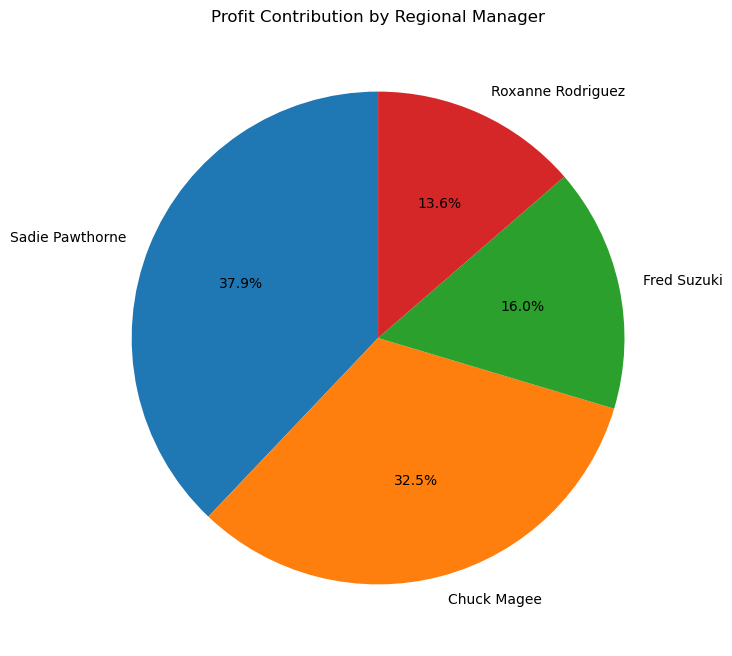

In [2398]:
viz_manager_profit= manager_profit.plot(
    kind='pie',
    y= 'Profit',
    labels=manager_profit['Regional Manager'],
    autopct='%1.1f%%',
    startangle=90,
    figsize=(8,8),
    legend=False)
viz_manager_profit.set_title('Profit Contribution by Regional Manager')
viz_manager_profit.set_ylabel('')

## Summary. Part 9

# Part 10. Key Metrics Forecast

## Objective
Project next year’s Sales and Profit based on historical monthly trends to estimate expected growth and assess future business performance under a baseline scenario.

## Tasks
1. Trend & Growth Analysis
3. Build Baseline Forecast Model
4. Compare Actual vs Forecast

## Trend & Growth Analysis

In [2424]:
monthly_ts = (orders.groupby('Year_Month').agg(
            Sales=('Sales', 'sum'),
            Profit=('Profit', 'sum')).sort_index())
monthly_ts.index = monthly_ts.index.to_timestamp()

In [2430]:
monthly_ts['Sales_MoM_%'] = (monthly_ts['Sales'].pct_change() * 100).round(2)

monthly_ts['Profit_MoM_%'] = (monthly_ts['Profit'].pct_change() * 100).round(2)

In [2432]:
monthly_ts['Sales_Rolling_3'] = (monthly_ts['Sales'].rolling(3).mean())

monthly_ts['Profit_Rolling_3'] = (monthly_ts['Profit'].rolling(3).mean())

In [2436]:
monthly_ts['Sales_YoY_%'] = (monthly_ts['Sales'].pct_change() * 100).round(2)

monthly_ts['Profit_YoY_%'] = (monthly_ts['Profit'].pct_change() * 100).round(2)

In [2440]:
years_diff = (monthly_ts.index.max().year - monthly_ts.index.min().year)

sales_avg_annual_growth = ((monthly_ts['Sales'].iloc[-1] / monthly_ts['Sales'].iloc[0]) ** (1 / years_diff) - 1) * 100

profit_avg_annual_growth = ((monthly_ts['Profit'].iloc[-1] / monthly_ts['Profit'].iloc[0]) ** (1 / years_diff) - 1) * 100

## Baseline Forecast Model

In [2448]:
x=np.arange(len(monthly_ts))

In [2450]:
sales_trend = np.poly1d(np.polyfit(x, monthly_ts['Sales'], 1))

In [2452]:
profit_trend = np.poly1d(np.polyfit(x, monthly_ts['Profit'], 1))

In [2454]:
future_x = np.arange(len(monthly_ts), len(monthly_ts) + 12)

future_dates = pd.date_range(
    start=monthly_ts.index[-1] + pd.offsets.MonthBegin(1),
    periods=12,
    freq='MS'
)

In [2456]:
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast_Sales': sales_trend(future_x),
    'Forecast_Profit': profit_trend(future_x)
})

In [2460]:
forecast_df

,Date,Forecast_Sales,Forecast_Profit
0,2026-01-01,70799.191972,9543.821573
1,2026-02-01,71710.609370,9684.813598
2,2026-03-01,72622.026768,9825.805622
3,2026-04-01,73533.444166,9966.797647
4,2026-05-01,74444.861565,10107.789671
5,2026-06-01,75356.278963,10248.781696
6,2026-07-01,76267.696361,10389.773720
7,2026-08-01,77179.113759,10530.765745
8,2026-09-01,78090.531158,10671.757770
9,2026-10-01,79001.948556,10812.749794


In [2462]:
forecast_df = forecast_df.set_index('Date')

In [2464]:
combined_sales = pd.concat([monthly_ts['Sales'], forecast_df['Forecast_Sales']])

combined_profit = pd.concat([monthly_ts['Profit'], forecast_df['Forecast_Profit']])

Text(0, 0.5, 'Sales')

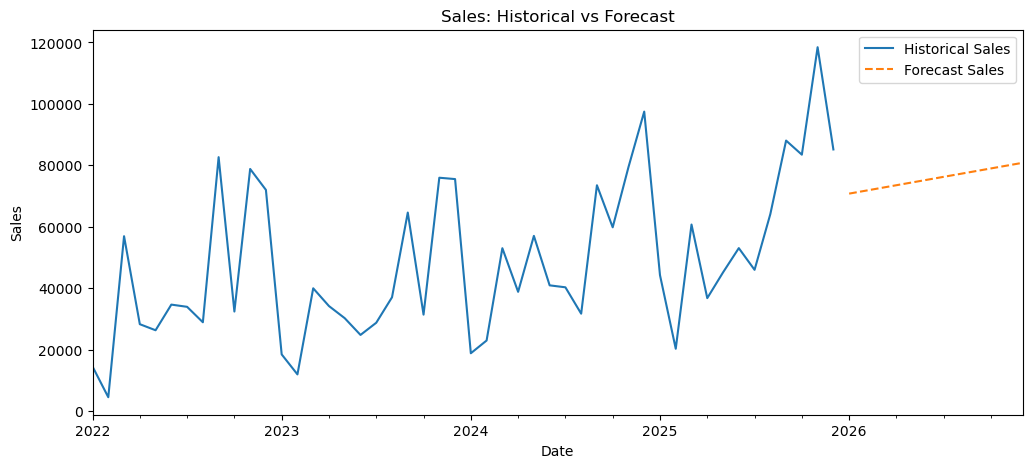

In [2468]:
sales_plot = pd.concat(
    [
        monthly_ts['Sales'],
        forecast_df['Forecast_Sales']
    ],
    axis=1
)

sales_plot.columns = ['Historical Sales', 'Forecast Sales']

ax = sales_plot.plot(
    figsize=(12,5),
    style=['-', '--']
)

ax.set_title('Sales: Historical vs Forecast')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')

Text(0, 0.5, 'Profit')

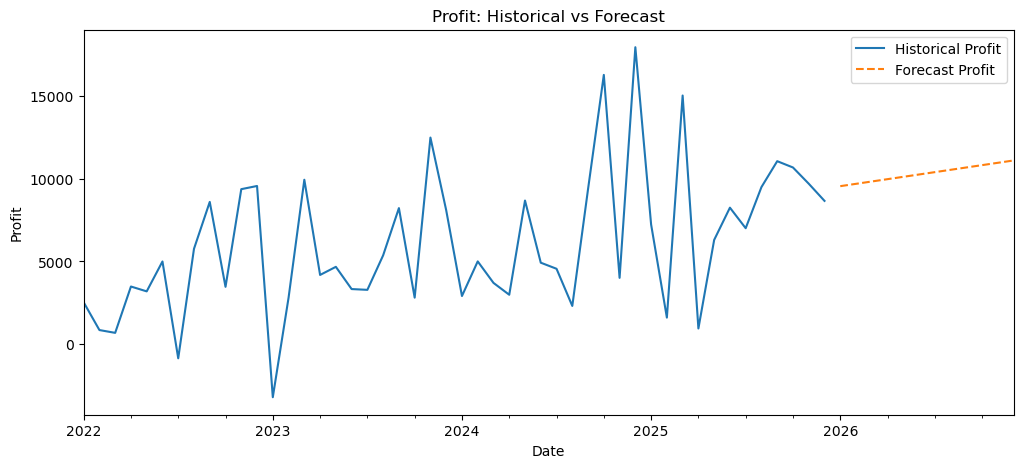

In [2470]:
profit_plot = pd.concat(
    [
        monthly_ts['Profit'],
        forecast_df['Forecast_Profit']
    ],
    axis=1
)

profit_plot.columns = ['Historical Profit', 'Forecast Profit']

ax = profit_plot.plot(
    figsize=(12,5),
    style=['-', '--']
)

ax.set_title('Profit: Historical vs Forecast')
ax.set_xlabel('Date')
ax.set_ylabel('Profit')


## Compare Actual vs Forecast


In [2486]:
last_year = monthly_ts.index.year.max()

actual_last_year_sales = (monthly_ts[monthly_ts.index.year == last_year]['Sales'].sum())

actual_last_year_profit = (monthly_ts[monthly_ts.index.year == last_year]['Profit'].sum())

In [2488]:
forecast_sales_next_year = forecast_df['Forecast_Sales'].sum().round(0)
forecast_profit_next_year = forecast_df['Forecast_Profit'].sum().round(0)

In [2500]:
sales_growth_forecast = ((forecast_sales_next_year / actual_last_year_sales - 1) * 100).round(1)
profit_growth_forecast = ((forecast_profit_next_year / actual_last_year_profit - 1) * 100).round(1)

In [2514]:
comparison_table = pd.DataFrame({
    'Metric': ['Sales', 'Profit'],
    'Actual Last Year': [actual_last_year_sales,actual_last_year_profit],
    'Forecast Next Year': [forecast_sales_next_year,forecast_profit_next_year],
    'Forecast Growth %': [sales_growth_forecast,profit_growth_forecast]}).round(1)

In [2518]:
comparison_table

,Metric,Actual Last Year,Forecast Next Year,Forecast Growth %
0,Sales,745567.5,909744.0,22.0
1,Profit,95926.3,123831.0,29.1


[Text(0, 0, 'Sales'), Text(1, 0, 'Profit')]

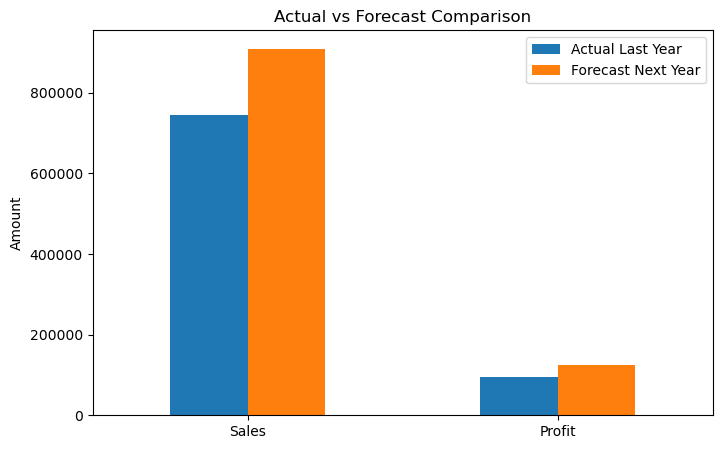

In [2540]:
bar_data = comparison_table.set_index('Metric')[[
    'Actual Last Year',
    'Forecast Next Year']]

viz_bar_data = bar_data.plot(
    kind='bar',
    figsize=(8,5)
)

viz_bar_data.set_title('Actual vs Forecast Comparison')
viz_bar_data.set_ylabel('Amount')
viz_bar_data.set_xlabel('')
viz_bar_data.legend(title='')
viz_bar_data.set_xticklabels(
    viz_bar_data.get_xticklabels(),
    rotation=0
)

## Summary. Part 10